In [1]:
import pandas as pd

data = pd.read_csv('reviews.csv')
data = data.head(10000)
data.tail()

,Time_submitted,Review,Rating,Total_thumbsup,Reply
9995,2022-06-17 09:34:24,Please make sure that the panels don't lag on ...,3,0,NaN
9996,2022-06-17 09:32:57,"This app has become a problem, why do you alwa...",1,0,NaN
9997,2022-06-17 09:20:21,"The app is good, but the lyric won't show for ...",5,0,NaN
9998,2022-06-17 09:17:26,Good App..Doesn't have ads between songs and h...,4,0,NaN
9999,2022-06-17 09:14:54,Impossible to use on lock screen anymore. Trie...,2,0,NaN


In [2]:
data.isnull().sum()

Time_submitted       0
Review               0
Rating               0
Total_thumbsup       0
Reply             9979
dtype: int64

In [3]:
data.drop(['Time_submitted', 'Reply'], axis=1, inplace=True)
data.isnull().sum()

Review            0
Rating            0
Total_thumbsup    0
dtype: int64

C:\Users\user\AppData\Local\Temp\ipykernel_8376\4234130059.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=data, palette='pastel')


<Axes: xlabel='Rating', ylabel='count'>

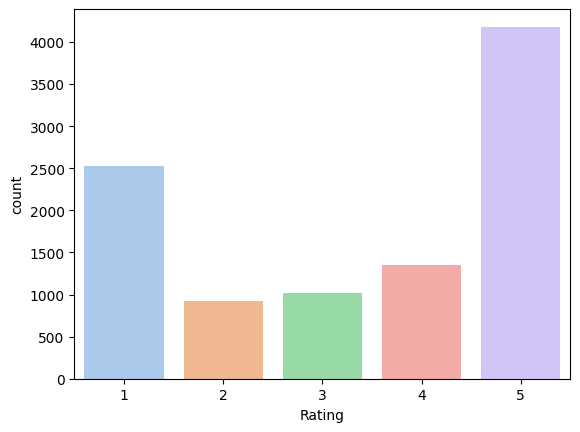

In [4]:
import seaborn as sns
sns.countplot(x='Rating', data=data, palette='pastel')

In [5]:
def transform_ratings(rating):
    if rating == 5 or rating == 4:
        return "Good"
    if rating == 3:
            return "Neutral"
    if rating == 2 or rating == 1:
        return "Bad"

C:\Users\user\AppData\Local\Temp\ipykernel_8376\2172474380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Desc', data=data, palette='pastel')


,Review,Rating,Total_thumbsup,Desc,length
0,"Great music service, the audio is high quality...",5,2,Good,112
1,Please ignore previous negative rating. This a...,5,1,Good,86
2,"This pop-up ""Get the best Spotify experience o...",4,0,Good,106
3,Really buggy and terrible to use as of recently,1,1,Bad,47
4,Dear Spotify ... why do I get songs that I di...,1,1,Bad,105


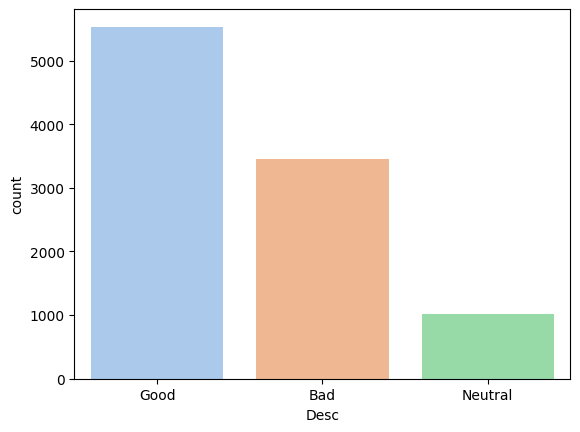

In [6]:
data['Desc'] = data['Rating'].apply(transform_ratings)
data['length'] = data['Review'].str.len()
sns.countplot(x='Desc', data=data, palette='pastel')
data.head()

<Axes: xlabel='length', ylabel='Total_thumbsup'>

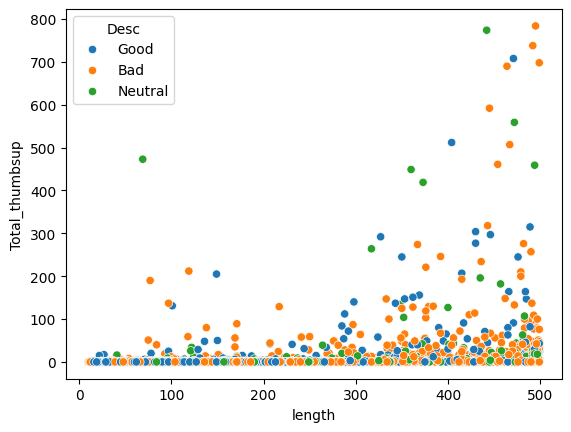

In [7]:
sns.scatterplot(x=data['length'][data.length < 500], y=data['Total_thumbsup'][data.Total_thumbsup < 800], hue=data['Desc'])

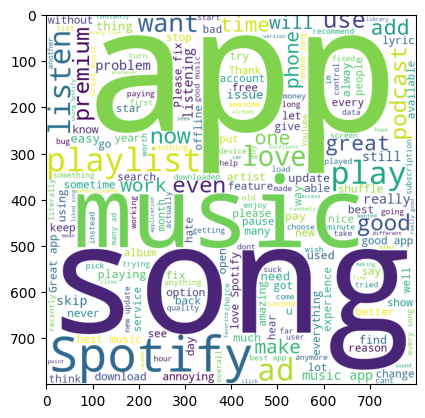

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

reviews = " ".join(data.loc[:, 'Review'])
wordcloud = WordCloud(width=800, height=800, background_color='white', min_font_size=10).generate(reviews)
plt.imshow(wordcloud)

In [9]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

data.loc[:, 'Review'] = data.loc[:, 'Review'].apply(lambda x: " ".join(x.lower() for x in x.split()))
data.loc[:, 'Review'] = data.loc[:, 'Review'].apply(lambda word: re.sub(r'[^a-z A-Z 0-9-]', ' ', word))

stop_words = stopwords.words('english')
data.loc[:, 'Review'] = data.loc[:, 'Review'].apply(lambda word: " ".join(word for word in word.split() if word not in stop_words))

stemmer = PorterStemmer()
data.loc[:, 'Review'] = data.loc[:, 'Review'].apply(lambda word: " ".join(stemmer.stem(word) for word in word.split()))

data.head()['Review']

0    great music servic audio high qualiti app easi...
1    pleas ignor previou neg rate app super great g...
2    pop-up get best spotifi experi android 12 anno...
3                      realli buggi terribl use recent
4       dear spotifi get song put playlist shuffl play
Name: Review, dtype: object

In [10]:
from sklearn.model_selection import train_test_split

x = data['Review']
y = data['Desc']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=40)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((7500,), (2500,), (7500,), (2500,))

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(y_train)
y_train = le.transform(y_train)
y_test = le.transform(y_test)
y_train

array([2, 1, 1, ..., 0, 1, 1])

In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
cv.fit(x_train)
x_train_count = cv.transform(x_train)
x_test_count = cv.transform(x_test)
print(x_train_count)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 89149 stored elements and shape (7500, 5250)>
  Coords	Values
  (0, 248)	1
  (0, 2663)	1
  (0, 2944)	1
  (0, 3416)	1
  (0, 3426)	1
  (0, 4219)	1
  (0, 4921)	1
  (1, 429)	1
  (1, 1749)	1
  (1, 2767)	1
  (1, 3192)	1
  (1, 3346)	1
  (1, 4306)	1
  (2, 1568)	1
  (2, 1674)	1
  (2, 2045)	1
  (2, 3018)	1
  (3, 8)	1
  (3, 575)	1
  (3, 2014)	1
  (3, 2608)	1
  (3, 2686)	1
  (3, 3240)	1
  (3, 3345)	1
  (3, 3351)	1
  :	:
  (7497, 2737)	1
  (7497, 3075)	1
  (7497, 3168)	2
  (7497, 3201)	1
  (7497, 3481)	1
  (7497, 3546)	2
  (7497, 3672)	1
  (7497, 4080)	2
  (7497, 4204)	1
  (7497, 4228)	1
  (7497, 4563)	1
  (7497, 4687)	1
  (7497, 4725)	1
  (7497, 4921)	2
  (7497, 5029)	1
  (7497, 5091)	2
  (7497, 5122)	1
  (7497, 5155)	1
  (7497, 5215)	1
  (7498, 660)	1
  (7498, 3426)	1
  (7498, 4219)	1
  (7499, 539)	1
  (7499, 3456)	1
  (7499, 4356)	1


In [13]:
tfidf = TfidfVectorizer(analyzer='char', ngram_range=(2, 3))
tfidf.fit(x_train)

x_train_tfidf = tfidf.transform(x_train)
x_test_tfidf = tfidf.transform(x_test)
print(x_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 882793 stored elements and shape (7500, 6978)>
  Coords	Values
  (0, 152)	0.06258029005488948
  (0, 162)	0.11962209925903149
  (0, 359)	0.07756993796082792
  (0, 364)	0.17366520772452956
  (0, 426)	0.1445319035382517
  (0, 437)	0.19054201008123664
  (0, 469)	0.061626405698486125
  (0, 483)	0.08923125632744815
  (0, 511)	0.10224175778581465
  (0, 525)	0.12720082634804
  (0, 1476)	0.09643234724433847
  (0, 1477)	0.11492107741561604
  (0, 1737)	0.17126962030179385
  (0, 1738)	0.09671330172265521
  (0, 1745)	0.13991449880002216
  (0, 2168)	0.07227690548259778
  (0, 2195)	0.15651253595363931
  (0, 2404)	0.06774582511981246
  (0, 2427)	0.160633473979933
  (0, 2703)	0.10192446196244616
  (0, 2704)	0.12345613671879135
  (0, 2930)	0.08687268924950473
  (0, 2940)	0.16374228230757723
  (0, 3578)	0.17567079564789953
  (0, 3597)	0.18076808962405816
  :	:
  (7499, 1710)	0.1754084756814553
  (7499, 1712)	0.24826753519636588
  (7499, 1993)	

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf1 = RandomForestClassifier()
rf1.fit(x_train_count, y_train)
rf_cv = rf1.score(x_test_count, y_test)
print(f'Random Forest Classifier on Count Vectors: {rf_cv}')

Random Forest Classifier on Count Vectors: 0.7656


In [15]:
rf2 = RandomForestClassifier()
rf2.fit(x_train_tfidf, y_train)
rf_tfidf = rf2.score(x_test_tfidf, y_test)
print(f'Random Forest Classifier on TF-IDF: {rf_tfidf}')

Random Forest Classifier on TF-IDF: 0.756


In [16]:
from sklearn.naive_bayes import MultinomialNB

mnb1 = MultinomialNB()
mnb1.fit(x_train_count, y_train)
mnb_cv = mnb1.score(x_test_count, y_test)
print(f'M Naive Bayes Classifier on CV: {mnb_cv}')

M Naive Bayes Classifier on CV: 0.7736


In [17]:
from sklearn.naive_bayes import MultinomialNB

mnb2 = MultinomialNB()
mnb2.fit(x_train_tfidf, y_train)
mnb_tfidf = mnb2.score(x_test_tfidf, y_test)
print(f'M Naive Bayes Classifier on TF-IDF: {mnb_tfidf}')

M Naive Bayes Classifier on TF-IDF: 0.7564


In [18]:
model = {'model': ['RF-Count', 'RF-TFIDF', 'MNB-Count', 'MNB-TFIDF'],
         'score': [rf_cv, rf_tfidf, mnb_cv, mnb_tfidf]}
model_df= pd.DataFrame(model)
model_df

,model,score
0,RF-Count,0.7656
1,RF-TFIDF,0.7560
2,MNB-Count,0.7736
3,MNB-TFIDF,0.7564


<Axes: xlabel='score', ylabel='model'>

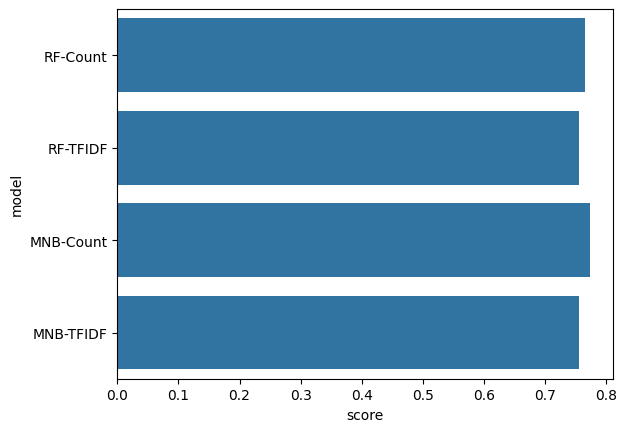

In [19]:
sns.barplot(data=model_df, y='model', x='score')

Text(0.5, 1.0, 'Confusion Matrix M NaiveBayes-Count')

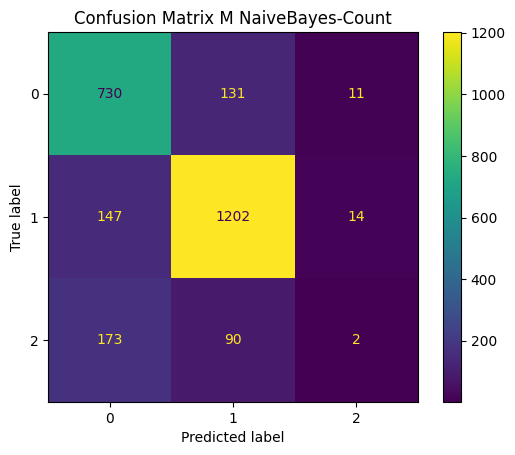

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(mnb1, x_test_count, y_test)
disp.ax_.set_title("Confusion Matrix M NaiveBayes-Count")

In [21]:
import pickle 

with open('model.pkl', 'wb') as f:
    pickle.dump(mnb1, f)
with open('transformer.pkl', 'wb') as f:
    pickle.dump(cv, f)
with open('le.pkl', 'wb') as f:
    pickle.dump(le, f)

In [22]:
test_reviews = ['This is a great app!', 'No control options from my phones', 'I like the song selection, but the ads are annoying', 'bad ui']
pred = mnb1.predict(cv.transform(test_reviews))
pred_transformed = le.inverse_transform(pred).tolist()

In [23]:
result = pd.DataFrame({'Reviews': test_reviews, 'Outcome': pred_transformed})
result

,Reviews,Outcome
0,This is a great app!,Good
1,No control options from my phones,Bad
2,"I like the song selection, but the ads are ann...",Bad
3,bad ui,Bad


C:\Users\user\AppData\Local\Temp\ipykernel_8376\2762034735.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=result, palette='pastel')


<Axes: xlabel='Outcome', ylabel='count'>

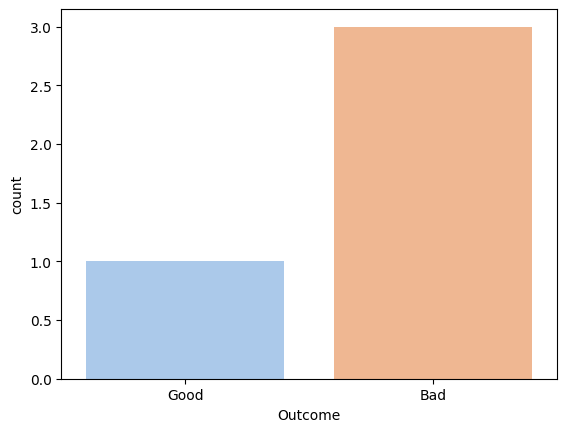

In [24]:
sns.countplot(x='Outcome', data=result, palette='pastel')

In [25]:
with open("test_review.txt", "r", encoding='utf-8') as f:
    content = f.read()
    data_review = content.split("\n")
data_review

['Lol music quality is good but the ads are just kinda annoying and when im sleeping and listening to Spotify the ads are just kinda really annoying in my phone theres no repeat for the song since i always like my music in repeat for other i dont know i guess they have the repeat button but i dont have the repeat song button so yeah i only hibe it 4 stars.',
 'I like the music but hate the cancellation and removable of truth. Stop being woke',
 "The canvas option isn't working for me anymore, so I can't enter a contest to win tickets for one of my favorite artists' release party 😡😡",
 'Sound quality is great...',
 "I didn't even done anything and it logout by itself and now i can't even log in also the phone no log in is not even showing i am really mad with this kind of survice",
 'provides very good music, helps me relax',
 "Most of the songs i personally listen in Spotify are EXPLICIT👈🏽 and that means (Spotify can't play this right now)🤦🏽\u200d♂️ As a Premium member im really disapp

In [26]:
import pickle

with open('model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('transformer.pkl', 'rb') as f:
    cv = pickle.load(f)
with open('le.pkl', 'rb') as f:
    le = pickle.load(f)

pred = model.predict(cv.transform(data_review))
pred_transformed = le.inverse_transform(pred).tolist()

In [27]:
result = pd.DataFrame({'Reviews': data_review, 'Outcome': pred_transformed})
result

,Reviews,Outcome
0,Lol music quality is good but the ads are just...,Neutral
1,I like the music but hate the cancellation and...,Bad
2,The canvas option isn't working for me anymore...,Neutral
3,Sound quality is great...,Good
4,I didn't even done anything and it logout by i...,Bad
...,...,...
96,"Ossm for music lovers,it's really good",Good
97,I listen to all my podcast and music with a vi...,Good
98,Lovely interface and wonderful app overall.,Good
99,"Extremely deceptive app, was given a 2 month p...",Good


C:\Users\user\AppData\Local\Temp\ipykernel_8376\2762034735.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=result, palette='pastel')


<Axes: xlabel='Outcome', ylabel='count'>

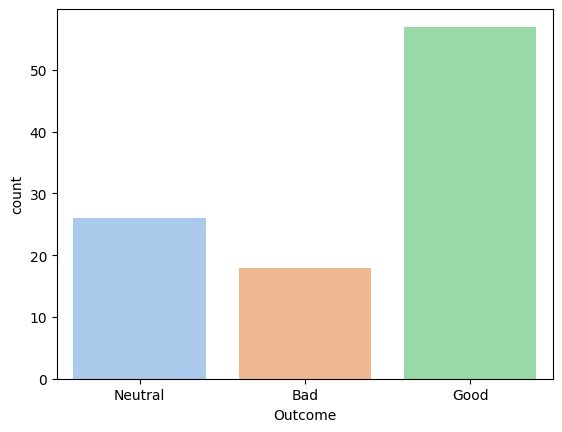

In [28]:
sns.countplot(x='Outcome', data=result, palette='pastel')